In [ ]:
ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.
If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

# エラー解消のため別に環境を作成
% conda create -n old_env python=3.12
% conda activate old_env
% pip install "numpy<2"

% pip show numpy                  
Name: numpy
Version: 1.26.4


###### カウントベースの手法の問題点
###### 学習データを一度にまとめて処理するので計算量が膨大になりえる
###### → 学習データの一部を使って逐次的に学習する（推論ベースの手法）

######
###### 推論ベースの手法
###### 周囲の単語（コンテキスト）が与えられたときに、その中心にどのような単語が出現するのかを推測する

###### ・ニューラルネットワークで単語を処理するために、単語を固定長のベクトルに変換する
###### ex)one-hot表現...ベクトルの要素の1つだけが1で、それ以外は0であるようなベクトル
|  単語 | 単語ID | one-hot表現 |
|------|-------|-----|
| you  | 0     | [1,0,0,0,0,0,0]   |
| goodbye  | 2     | [0,0,1,0,0,0,0]   |

In [5]:
# 全層結合による変換
import numpy as np
c = np.array([[1,0,0,0,0,0,0,]]) # 入力
W = np.random.randn(7,3)         # 重み
h = np.dot(c,W)                  # 中間ノード
print(h)

[[-2.11272667  1.19542788 -1.47759771]]


###### ※補足
###### word2vecは本来はプログラムやツール類を指す
###### CBOWモデルとskip-gramモデルがword2vecで使用されるニューラルネットワーク

######
###### CBOW(continuous bag-of-words)モデル
###### ...コンテキストからターゲットを推測することを目的としたニューラルネットワークモデル

In [ ]:
(base) sanonanari@snnnrnoMacBook-Air deep-learning-from-scratch-2 % python ch03/cbow_predict.py
[[-0.04357728 -0.84741736 -0.95511671  0.06897947 -1.16495341 -1.03033461
   0.28229941]]

######
###### word2vecで使用されるネットワークには2つの重みがある
###### ・入力側の全結合層の重み（Win）
###### Winの各行が各単語の分散表現に対応する
###### ・出力側の全結合層の重み(Wout)
###### Woutにも、単語の意味がエンコードされたベクトルが格納されている
######
###### 最終的に利用する単語の分散表現は3パターン
###### A.入力側の重みのみ ← よくある
###### B.出力側の重みのみ
###### C.両方の重みを利用 ex)2つの重みを足し合わせる

####
##### ch03/train.py の実行結果
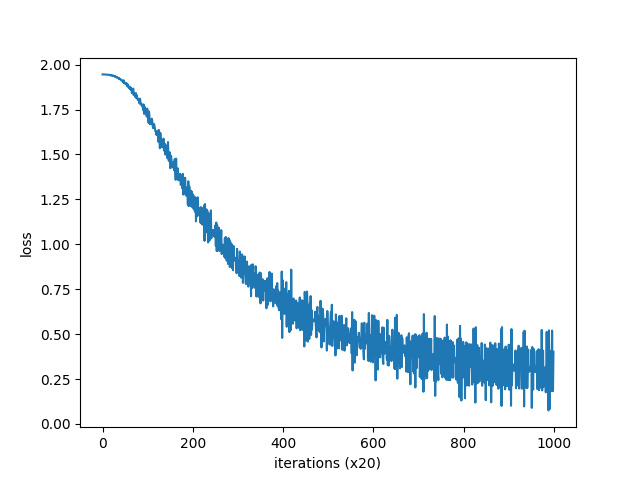

In [ ]:
you [ 1.0901369 -1.0296274  1.0134372 -1.0148193 -1.6754577]
say [-0.07143587  1.2737907  -1.2435341   1.2175075   0.43355605]
goodbye [ 1.0222639  -0.906552    0.94903    -0.954311    0.80588645]
and [-1.5492984   1.0067458  -0.99585366  0.96246403  1.5325737 ]
i [ 1.0084057  -0.89395255  0.9369904  -0.9520813   0.81196433]
hello [ 1.0839272 -1.0298135  1.0199656 -1.0143325 -1.6884042]
. [ 1.4666477  1.1007442 -1.1031758  1.0665659 -1.3695298]
# コーパスのサイズが小さすぎるため、良い結果ではない

####
##### CBOWモデルと確率
###### $w_1,w_2,...,w_T$という単語の列で表されるコーパスを扱うことにする
###### ここで、$t$番目の単語に対して、ウィンドウサイズが1のコンテキストを考える。
###### コンテキストとして$w_{t-1}とw_{t+1}$が与えられたときに、ターゲットが$w_t$となる確率は
###### $$P(w_t|w_{t-1},w_{t+1})$$
###### → CBOWはこの式をモデル化している
######
###### この式を用いてCBOWモデルの損失関数を表すと、
###### $$ 交差エントロピー誤差 L = -logP(w_t|w_{t-1},w_{t+1})$$
###### この式は「負の対数尤度」呼ばれる
######
###### 先ほどの式は一つのサンプルデータに関する損失関数なので、これをコーバス全体に拡張すると、
###### $$L = -\frac{1}{T} \sum_{t=1}^{T} \log P(w_t | w_{t-1}, w_{t+1})$$

####
##### skip-gramモデル
###### ...CBOWで扱うコンテキストデータとターゲットを逆転させたモデル。
######
###### 同様に確率の表記を用いてskip-gramモデルを表す
###### ターゲットを$w_t$として、そこからコンテキストの$w_{t-1}とw_{t+1}$を推測する場合、
###### $$P(w_{t-1},w_{t+1}|w_t)$$
###### ここで、コンテキストの単語ないだに関連性がないと仮定すると、
###### $$P(w_{t-1},w_{t+1}|w_t) = P(w_{t-1},|w_t)P(w_{t+1},|w_t)$$
###### よって、skip-gramモデルの損失関数は、
###### $$ L = -logP(w_{t-1},w_{t+1}|w_t) $$
###### $$   = -logP(w_{t-1},|w_t)P(w_{t+1},|w_t) $$
###### $$   = -(logP(w_{t-1},|w_t)+logP(w_{t+1},|w_t)) $$
###### のように、コンテキスト分の損失をそれぞれ求めて、それらを足し合わせたものになる。
###### これをこーバス全体に拡張すると、
###### $$L = -\frac{1}{T} \sum_{t=1}^{T} \ (logP(w_{t-1},|w_t)+logP(w_{t+1},|w_t))$$
####
###### skip-gramモデルの方がCBOWモデルより良い結果が得られることが多い。
###### 一方、学習速度の点ではCBOWモデルの方が高速。

####
##### カウントベース v.s. 推論ベース
##### <カウントベース>
###### ・コーバスの全体の統計データから1回の学習で単語の分散表現を得る
###### ・語彙に新しい単語を追加したいとき、ゼロから一連の計算をやりなおす必要がある
###### ・単語の分散表現には、主に単語の類似性がエンコードされる
##### <推論ベース>
###### ・コーバスの一部を何度も見ながら学習する（ミニバッチ学習）
###### ・語彙に新しい単語を追加したいとき、これまでに学習した重みを初期値として再学習できる
###### ・単語の分散表現には、単語の類似性に加えて、さらに複雑な単語間のパターンも捉えられる
######
###### 補足：単語の類似性に関する定量評価に関して言えば、どちらも精度は同程度